# 🥉 Extreme Rainfall Risk Atlas — India, 1901–2017

### A leakage-controlled multi-task Transformer for subdivision-level extreme-rainfall probability

**Scientific question**

> **Where in India does the model have genuine skill in anticipating rainfall extremes, and how does that skill change with forecast horizon?**

For each IMD subdivision \(i\), the model uses a **training-period 95th percentile threshold**:

\[
Q_{95,i}
\]

and defines the extreme-event target:

\[
E_{i,t}=1(R_{i,t}>Q_{95,i})
\]

The multi-task Transformer has three heads:

```text
24 monthly observations × 36 IMD subdivisions
                    │
                    ▼
          Temporal Transformer
                    │
        ┌───────────┼───────────┐
        ▼           ▼           ▼
    Rainfall     Extreme      Quantile
    forecast    probability    forecast
        │           │           │
        └───────────┼───────────┘
                    ▼
       1, 2, 3-month forecast horizons
```

### Outputs

- Rainfall forecasts
- \(P(E_{i,t+k}=1)\)
- 0.95 conditional quantile forecasts
- AUROC
- AUPRC
- Brier score
- Expected Calibration Error (ECE)
- Brier Skill Score against climatology
- **Genuine Skill = AUROC − 0.5**
- Reliability diagrams
- Horizon-wise skill decay
- An **actual IMD subdivision polygon risk atlas**

> **Leakage control:** thresholds, scaling parameters and imputation climatologies are fitted using the training period only. Validation/test windows may use historical context before the split boundary, but their target months remain strictly out-of-sample.

In [1]:
# ============================================================
# CELL 1 — Reproducibility, imports and Kaggle configuration
# ============================================================
import os, sys, glob, json, math, random, warnings, subprocess, importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

Device: cpu
PyTorch: 2.8.0+cpu


In [2]:
# ============================================================
# CELL 2 — Optional Kaggle dependencies
# ============================================================
# The notebook does NOT generate synthetic rainfall if the real
# dataset is absent. It fails loudly instead.

packages = {
    "sklearn": "scikit-learn",
    "geopandas": "geopandas",
    "shapely": "shapely",
    "requests": "requests",
}

missing = [imp for imp in packages if importlib.util.find_spec(imp) is None]
if missing:
    print("Installing:", [packages[x] for x in missing])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        *[packages[x] for x in missing]
    ])

import geopandas as gpd
import requests

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    mean_squared_error, mean_absolute_error
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

print("Optional dependencies ready.")

Installing: ['geopandas', 'shapely']



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Optional dependencies ready.


In [3]:
# ============================================================
# CELL 3 — Robustly discover the actual IMD rainfall CSV
# ============================================================
INPUT_ROOT = Path("/kaggle/input")

csv_candidates = sorted(INPUT_ROOT.rglob("*.csv"))
print(f"CSV files discovered: {len(csv_candidates)}")
for p in csv_candidates[:50]:
    print(" ", p)

preferred = [
    p for p in csv_candidates
    if "sub" in p.name.lower() and "division" in p.name.lower()
]

if not preferred:
    preferred = [
        p for p in csv_candidates
        if "rain" in p.name.lower()
    ]

if not preferred:
    raise FileNotFoundError(
        "No suitable rainfall CSV was found under /kaggle/input. "
        "Attach the Kaggle dataset containing Sub_Division_IMD_2017.csv."
    )

DATA_PATH = preferred[0]
print("\nSelected:", DATA_PATH)

CSV files discovered: 1
  /kaggle/input/datasets/vijayveersingh/indias-rainfall-data/Sub_Division_IMD_2017.csv

Selected: /kaggle/input/datasets/vijayveersingh/indias-rainfall-data/Sub_Division_IMD_2017.csv


In [4]:
# ============================================================
# CELL 4 — Load and validate the raw schema
# ============================================================
raw = pd.read_csv(DATA_PATH)

MONTHS = ["JAN","FEB","MAR","APR","MAY","JUN",
          "JUL","AUG","SEP","OCT","NOV","DEC"]
SEASONS = ["JF","MAM","JJAS","OND"]

required = ["SUBDIVISION", "YEAR"] + MONTHS
missing_required = [c for c in required if c not in raw.columns]
if missing_required:
    raise ValueError(f"Required columns missing: {missing_required}")

df = raw.copy()
df["SUBDIVISION"] = (
    df["SUBDIVISION"].astype(str).str.strip()
    .str.replace(r"\s+", " ", regex=True)
)
df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce")

for c in MONTHS + SEASONS + (["ANNUAL"] if "ANNUAL" in df.columns else []):
    if c in df.columns:
        # Handles literal NA strings as missing values.
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["SUBDIVISION","YEAR"]).copy()
df["YEAR"] = df["YEAR"].astype(int)

if df.duplicated(["SUBDIVISION","YEAR"]).any():
    dup = df[df.duplicated(["SUBDIVISION","YEAR"], keep=False)]
    raise ValueError("Duplicate subdivision-year records detected.")

print("Shape:", df.shape)
print("Subdivisions:", df.SUBDIVISION.nunique())
print("Years:", df.YEAR.min(), "to", df.YEAR.max())
display(df.head())

Shape: (4188, 19)
Subdivisions: 36
Years: 1901 to 2017


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,JF,MAM,JJAS,OND
0,Andaman & Nicobar Islands,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,Andaman & Nicobar Islands,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,Andaman & Nicobar Islands,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,Andaman & Nicobar Islands,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,Andaman & Nicobar Islands,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [5]:
# ============================================================
# CELL 5 — Data-quality audit
# ============================================================
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": 100 * df.isna().mean(),
    "unique": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(audit)

print("\nDuplicate rows:", df.duplicated().sum())

coverage = (
    df.groupby("YEAR")["SUBDIVISION"].nunique()
      .rename("subdivisions_present")
)
display(coverage.head())
display(coverage.tail())

,dtype,missing,missing_pct,unique
ANNUAL,float64,26,0.620821,3770
OND,float64,13,0.310411,2411
NOV,float64,11,0.262655,1245
JJAS,float64,10,0.238777,3734
DEC,float64,10,0.238777,810
MAM,float64,9,0.214900,2288
JUL,float64,7,0.167144,3093
OCT,float64,7,0.167144,1958
MAR,float64,6,0.143266,989
JF,float64,6,0.143266,1226



Duplicate rows: 0


YEAR
1901    35
1902    35
1903    35
1904    35
1905    35
Name: subdivisions_present, dtype: int64

YEAR
2013    36
2014    36
2015    36
2016    36
2017    36
Name: subdivisions_present, dtype: int64

In [6]:
# ============================================================
# CELL 6 — Reshape annual rows into a monthly panel
# ============================================================
panel = df.melt(
    id_vars=["SUBDIVISION","YEAR"],
    value_vars=MONTHS,
    var_name="MONTH_NAME",
    value_name="RAINFALL"
)

month_map = {m:i+1 for i,m in enumerate(MONTHS)}
panel["MONTH"] = panel["MONTH_NAME"].map(month_map)
panel["DATE"] = pd.to_datetime(
    panel["YEAR"].astype(str) + "-" +
    panel["MONTH"].astype(str).str.zfill(2) + "-01"
)

panel = panel.sort_values(["SUBDIVISION","DATE"]).reset_index(drop=True)

# Reindex each subdivision to a complete monthly calendar.
all_dates = pd.date_range(
    panel.DATE.min().replace(day=1),
    panel.DATE.max().replace(day=1),
    freq="MS"
)

subdivisions = sorted(panel.SUBDIVISION.unique())

complete = []
for s in subdivisions:
    tmp = panel.loc[panel.SUBDIVISION == s, ["DATE","RAINFALL"]].set_index("DATE")
    tmp = tmp.reindex(all_dates)
    tmp["SUBDIVISION"] = s
    tmp["MONTH"] = tmp.index.month
    complete.append(tmp.reset_index().rename(columns={"index":"DATE"}))

panel = pd.concat(complete, ignore_index=True)
panel["YEAR"] = panel.DATE.dt.year
panel = panel[["SUBDIVISION","DATE","YEAR","MONTH","RAINFALL"]]

print("Monthly panel:", panel.shape)
print("Expected subdivisions:", len(subdivisions))
print("Date range:", panel.DATE.min(), "to", panel.DATE.max())

Monthly panel: (50544, 5)
Expected subdivisions: 36
Date range: 1901-01-01 00:00:00 to 2017-12-01 00:00:00


In [7]:
# ============================================================
# CELL 7 — Chronological train / validation / test split
# ============================================================
dates = pd.DatetimeIndex(sorted(panel.DATE.unique()))
n_dates = len(dates)

train_cut = dates[int(n_dates * 0.70)]
val_cut   = dates[int(n_dates * 0.85)]

TRAIN_START = dates[0]
TRAIN_END   = train_cut
VAL_START   = train_cut + pd.offsets.MonthBegin(1)
VAL_END     = val_cut
TEST_START  = val_cut + pd.offsets.MonthBegin(1)
TEST_END    = dates[-1]

print("TRAIN:", TRAIN_START.date(), "→", TRAIN_END.date())
print("VAL  :", VAL_START.date(), "→", VAL_END.date())
print("TEST :", TEST_START.date(), "→", TEST_END.date())

TRAIN: 1901-01-01 → 1982-11-01
VAL  : 1982-12-01 → 2000-06-01
TEST : 2000-07-01 → 2017-12-01


## ⚠️ Leakage-control principle

The original dataset contains `ANNUAL`, `JF`, `MAM`, `JJAS`, and `OND`, but the predictive model deliberately uses **only monthly rainfall**.

The following are learned from training data only:

1. Missing-value climatologies
2. Per-subdivision scaling
3. \(Q_{95,i}\) extreme thresholds
4. Training-only baselines

This prevents the future test period from influencing the definition of an "extreme".

In [8]:
# ============================================================
# CELL 8 — Training-only imputation climatology
# ============================================================
# We avoid interpolation across the validation/test period because
# doing so could use future observations. Missing values are replaced
# using subdivision × calendar-month medians learned from TRAIN only,
# with a global training month median as fallback.

train_mask = panel.DATE <= TRAIN_END

sub_month_median = (
    panel.loc[train_mask]
    .groupby(["SUBDIVISION","MONTH"])["RAINFALL"]
    .median()
)

global_month_median = (
    panel.loc[train_mask]
    .groupby("MONTH")["RAINFALL"]
    .median()
)

panel["RAINFALL_RAW"] = panel["RAINFALL"]

def impute_training_only(row):
    if pd.notna(row["RAINFALL"]):
        return row["RAINFALL"]
    key = (row["SUBDIVISION"], row["MONTH"])
    val = sub_month_median.get(key, np.nan)
    if pd.isna(val):
        val = global_month_median.get(row["MONTH"], np.nan)
    return val

panel["RAINFALL_IMPUTED"] = panel.apply(impute_training_only, axis=1)
panel["IMPUTED_FLAG"] = panel["RAINFALL_RAW"].isna().astype(int)

if panel["RAINFALL_IMPUTED"].isna().any():
    raise ValueError("Unresolved missing rainfall values remain.")

panel["RAINFALL_IMPUTED"] = panel["RAINFALL_IMPUTED"].clip(lower=0)

print("Original missing cells:", int(panel.RAINFALL_RAW.isna().sum()))
print("Remaining missing:", int(panel.RAINFALL_IMPUTED.isna().sum()))

Original missing cells: 358
Remaining missing: 0


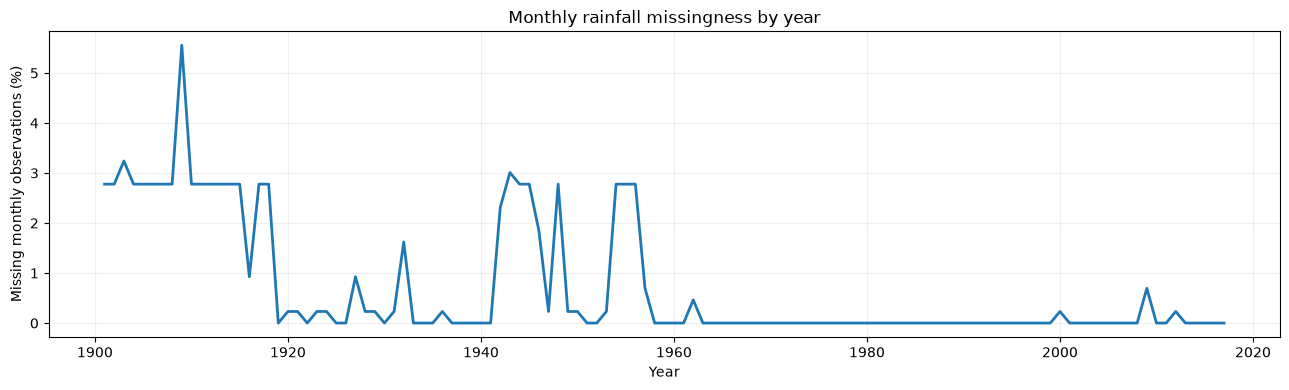

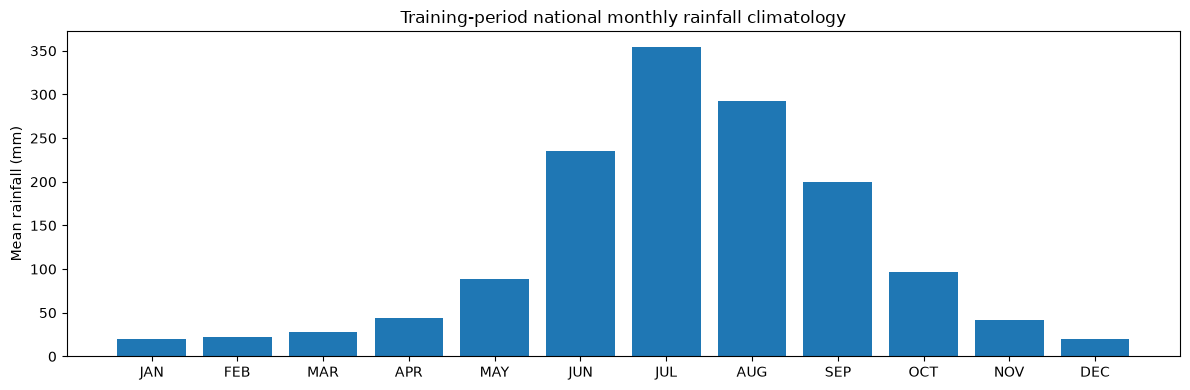

In [9]:
# ============================================================
# CELL 9 — Visual data-quality diagnostics
# ============================================================
fig, ax = plt.subplots(figsize=(13,4))
missing_by_year = (
    panel.assign(is_missing=panel.RAINFALL_RAW.isna())
         .groupby("YEAR").is_missing.mean() * 100
)
ax.plot(missing_by_year.index, missing_by_year.values, linewidth=2)
ax.set_title("Monthly rainfall missingness by year")
ax.set_xlabel("Year")
ax.set_ylabel("Missing monthly observations (%)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

monthly_clim = (
    panel[panel.DATE <= TRAIN_END]
    .groupby("MONTH")["RAINFALL_IMPUTED"].mean()
)

fig, ax = plt.subplots(figsize=(12,4))
ax.bar(range(1,13), monthly_clim.values)
ax.set_xticks(range(1,13), MONTHS)
ax.set_ylabel("Mean rainfall (mm)")
ax.set_title("Training-period national monthly rainfall climatology")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 10 — Define Q95 using TRAINING PERIOD ONLY
# ============================================================
train_values = panel.loc[train_mask].copy()

q95 = (
    train_values.groupby("SUBDIVISION")["RAINFALL_IMPUTED"]
    .quantile(0.95)
    .rename("Q95_TRAIN")
)

if q95.isna().any():
    raise ValueError("Some subdivisions have no training rainfall values.")

panel = panel.merge(q95, left_on="SUBDIVISION", right_index=True, how="left")

# Extreme-event target
panel["EXTREME"] = (
    panel["RAINFALL_IMPUTED"] > panel["Q95_TRAIN"]
).astype(np.float32)

print("Q95 threshold summary:")
display(q95.describe().to_frame())

print("\nTraining extreme-event rate:",
      round(panel.loc[train_mask, "EXTREME"].mean(), 4))

print("\nPer-subdivision event-rate range:")
display(
    panel.loc[train_mask].groupby("SUBDIVISION")["EXTREME"]
    .mean().describe().to_frame("event_rate")
)

Q95 threshold summary:


,Q95_TRAIN
count,36.000000
mean,412.428056
std,246.687764
min,119.650000
25%,246.987500
50%,357.785000
75%,451.582500
max,1129.690000



Training extreme-event rate: 0.0508

Per-subdivision event-rate range:


,event_rate
count,36.000000
mean,0.050808
std,0.000236
min,0.049847
25%,0.050865
50%,0.050865
75%,0.050865
max,0.050865


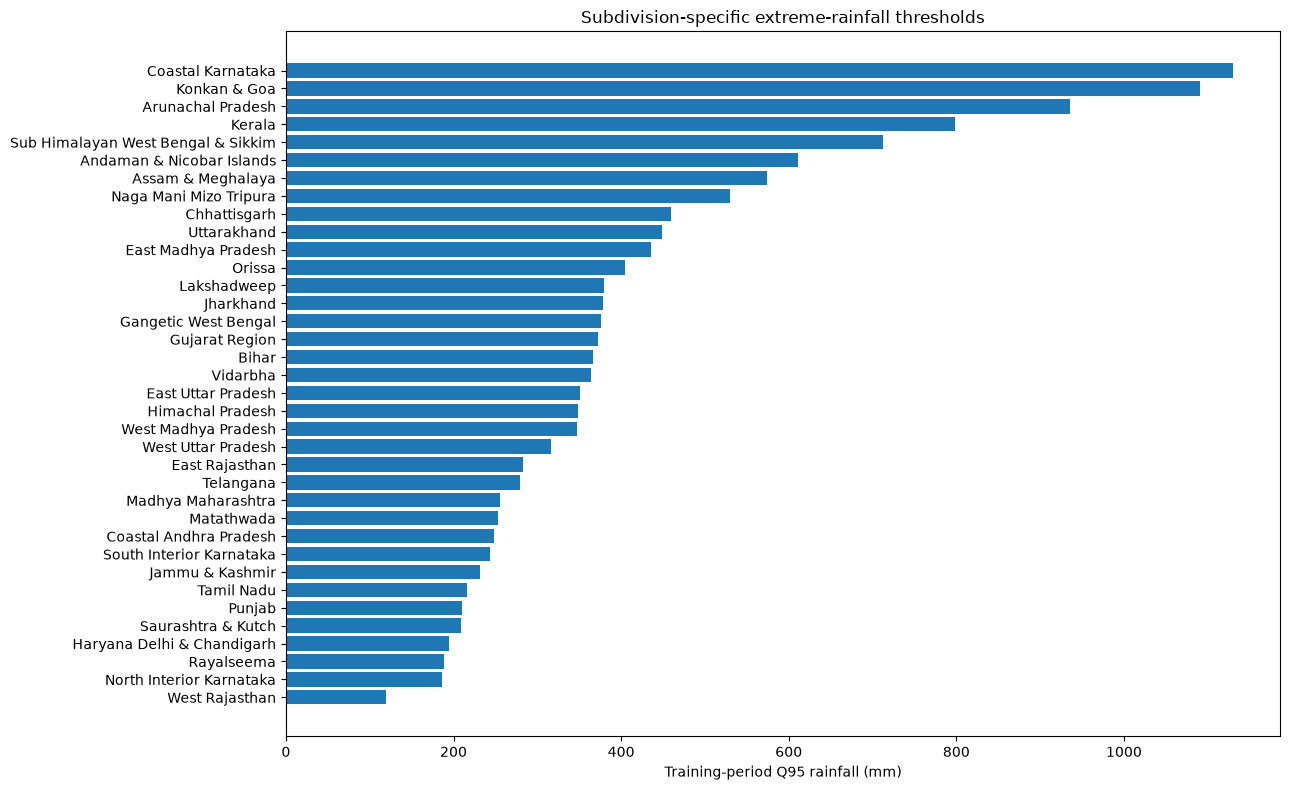

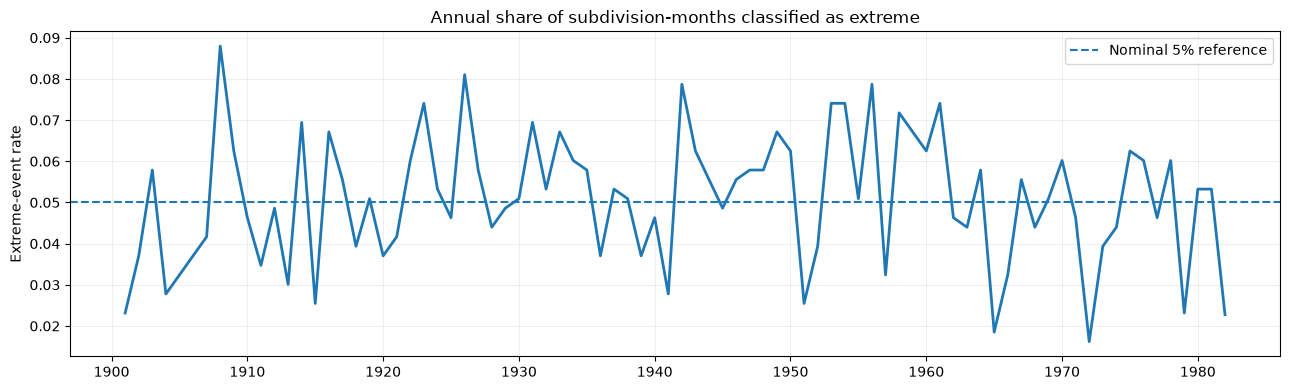

In [11]:
# ============================================================
# CELL 11 — Inspect rainfall thresholds and extreme events
# ============================================================
threshold_table = q95.reset_index().sort_values("Q95_TRAIN", ascending=False)

fig, ax = plt.subplots(figsize=(13,8))
ax.barh(
    threshold_table.SUBDIVISION[::-1],
    threshold_table.Q95_TRAIN[::-1]
)
ax.set_xlabel("Training-period Q95 rainfall (mm)")
ax.set_title("Subdivision-specific extreme-rainfall thresholds")
plt.tight_layout()
plt.show()

annual_extreme_rate = (
    panel.loc[train_mask]
    .groupby("YEAR")["EXTREME"].mean()
)

fig, ax = plt.subplots(figsize=(13,4))
ax.plot(annual_extreme_rate.index, annual_extreme_rate.values, linewidth=2)
ax.axhline(0.05, linestyle="--", label="Nominal 5% reference")
ax.set_title("Annual share of subdivision-months classified as extreme")
ax.set_ylabel("Extreme-event rate")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# CELL 12 — Build wide monthly matrices
# ============================================================
rain_wide = (
    panel.pivot(index="DATE", columns="SUBDIVISION", values="RAINFALL_IMPUTED")
    .reindex(columns=subdivisions)
    .sort_index()
)

extreme_wide = (
    panel.pivot(index="DATE", columns="SUBDIVISION", values="EXTREME")
    .reindex(columns=subdivisions)
    .sort_index()
)

q95_vec = q95.reindex(subdivisions).values.astype(np.float32)

assert not rain_wide.isna().any().any()
assert not extreme_wide.isna().any().any()

print("Rainfall matrix:", rain_wide.shape)
print("Extreme matrix:", extreme_wide.shape)

Rainfall matrix: (1404, 36)
Extreme matrix: (1404, 36)


In [13]:
# ============================================================
# CELL 13 — Training-only standardization
# ============================================================
# Each subdivision is standardized independently using only TRAIN.
# This prevents wetter regions from dominating the neural network.

train_rain = rain_wide.loc[:TRAIN_END]

means = train_rain.mean(axis=0)
stds = train_rain.std(axis=0).replace(0, 1.0)

rain_z = (rain_wide - means) / stds

print("Standardized matrix:", rain_z.shape)
display(
    pd.DataFrame({
        "mean_train_mm": means,
        "std_train_mm": stds,
        "Q95_train_mm": q95.reindex(subdivisions)
    }).head(10)
)

Standardized matrix: (1404, 36)


,mean_train_mm,std_train_mm,Q95_train_mm
SUBDIVISION,,,
Andaman & Nicobar Islands,247.191658,202.758372,611.34
Arunachal Pradesh,306.085249,307.272489,935.90
Assam & Meghalaya,216.849847,196.982236,573.73
Bihar,100.876704,127.989954,366.00
Chhattisgarh,117.464191,156.149374,459.18
Coastal Andhra Pradesh,86.945270,88.649409,248.30
Coastal Karnataka,280.602442,396.259301,1129.69
East Madhya Pradesh,103.793998,150.131787,435.52
East Rajasthan,55.912614,93.759565,283.31


## 🧠 Multi-task forecasting formulation

For every forecast origin \(t\), the model receives the previous 24 months:

\[
X_t =
[R_{t-23},...,R_t]
\]

and predicts the next three months simultaneously:

\[
\hat R_{t+1:t+3}
\]

\[
\hat P(E_{t+k}=1),\quad k=1,2,3
\]

\[
\hat Q_{0.95,t+k}
\]

The quantile head is trained with **pinball loss**, while the extreme head uses **weighted binary cross-entropy** to handle class imbalance.

In [14]:
# ============================================================
# CELL 14 — Sequence dataset
# ============================================================
LOOKBACK = 24
HORIZON = 3

rain_array = rain_z.values.astype(np.float32)
raw_rain_array = rain_wide.values.astype(np.float32)
extreme_array = extreme_wide.values.astype(np.float32)

date_values = rain_wide.index.to_numpy()

# Each sample target_start is the first future month.
def make_indices(start_date, end_date):
    valid = []
    for target_start in range(LOOKBACK, len(date_values) - HORIZON + 1):
        target_dates = date_values[target_start:target_start + HORIZON]
        if target_dates[0] >= np.datetime64(start_date) and target_dates[-1] <= np.datetime64(end_date):
            valid.append(target_start)
    return np.array(valid, dtype=np.int64)

train_idx = make_indices(TRAIN_START + pd.offsets.MonthBegin(1), TRAIN_END)
val_idx   = make_indices(VAL_START, VAL_END)
test_idx  = make_indices(TEST_START, TEST_END)

print("Samples — train:", len(train_idx), "val:", len(val_idx), "test:", len(test_idx))

class RainfallSequenceDataset(Dataset):
    def __init__(self, indices):
        self.indices = np.asarray(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, j):
        i = int(self.indices[j])

        x = rain_array[i-LOOKBACK:i]                 # [L,N]
        y_rain = raw_rain_array[i:i+HORIZON]        # [H,N]
        y_ext = extreme_array[i:i+HORIZON]          # [H,N]

        # Future Q95 is a fixed subdivision threshold.
        y_q = np.broadcast_to(
            q95_vec[None, :],
            (HORIZON, len(subdivisions))
        ).astype(np.float32)

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y_rain, dtype=torch.float32),
            torch.tensor(y_ext, dtype=torch.float32),
            torch.tensor(y_q, dtype=torch.float32),
        )

train_ds = RainfallSequenceDataset(train_idx)
val_ds = RainfallSequenceDataset(val_idx)
test_ds = RainfallSequenceDataset(test_idx)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Samples — train: 957 val: 209 test: 208


In [15]:
# ============================================================
# CELL 15 — Multi-task Temporal Transformer
# ============================================================
class MultiTaskRainfallTransformer(nn.Module):
    def __init__(
        self,
        n_nodes,
        lookback=24,
        d_model=128,
        nhead=8,
        num_layers=3,
        dropout=0.15,
        horizon=3
    ):
        super().__init__()

        self.n_nodes = n_nodes
        self.lookback = lookback
        self.horizon = horizon

        # Each time step contains all subdivisions.
        self.input_proj = nn.Linear(n_nodes, d_model)

        # Learnable temporal positional encoding.
        self.pos = nn.Parameter(torch.randn(1, lookback, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4*d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        out_dim = horizon * n_nodes

        # Three independent task heads.
        self.rain_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, out_dim)
        )

        self.extreme_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, out_dim)
        )

        self.quantile_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, out_dim)
        )

    def forward(self, x):
        z = self.input_proj(x)
        z = z + self.pos[:, :z.shape[1]]
        z = self.encoder(z)
        context = self.norm(z[:, -1])

        rain = self.rain_head(context).view(-1, self.horizon, self.n_nodes)
        extreme_logits = self.extreme_head(context).view(-1, self.horizon, self.n_nodes)

        # Quantile rainfall must be non-negative.
        quantile = F.softplus(
            self.quantile_head(context)
        ).view(-1, self.horizon, self.n_nodes)

        return rain, extreme_logits, quantile

model = MultiTaskRainfallTransformer(
    n_nodes=len(subdivisions),
    lookback=LOOKBACK,
    d_model=128,
    nhead=8,
    num_layers=3,
    dropout=0.15,
    horizon=HORIZON
).to(DEVICE)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

MultiTaskRainfallTransformer(
  (input_proj): Linear(in_features=36, out_features=128, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.15, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.15, inplace=False)
        (dropout2): Dropout(p=0.15, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (rain_head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2)

In [16]:
# ============================================================
# CELL 16 — Multi-task losses and training utilities
# ============================================================
# Extreme-event class weights are calculated from TRAIN only.
event_rate_train = float(extreme_array[LOOKBACK:len(train_rain)].mean())
pos_weight_value = max(1.0, (1.0-event_rate_train) / max(event_rate_train, 1e-6))
pos_weight = torch.tensor(pos_weight_value, device=DEVICE)

bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def pinball_loss(pred, target, q=0.95):
    err = target - pred
    return torch.maximum(q * err, (q - 1.0) * err).mean()

def multi_task_loss(
    pred_rain, pred_logits, pred_q,
    y_rain, y_ext, y_q,
    lambda_ext=1.0,
    lambda_q=0.35,
    lambda_rain=0.35
):
    # Rainfall regression is trained in standardized units.
    # Convert target rainfall to standardized target first.
    means_t = torch.tensor(means.values, dtype=torch.float32, device=DEVICE)
    stds_t = torch.tensor(stds.values, dtype=torch.float32, device=DEVICE)
    y_rain_z = (y_rain - means_t[None,None,:]) / stds_t[None,None,:]

    # Quantile target remains in mm, so pred_q is in mm.
    loss_ext = bce_loss(pred_logits, y_ext)
    loss_q = pinball_loss(pred_q, y_q, q=0.95)
    loss_rain = F.smooth_l1_loss(pred_rain, y_rain_z)

    total = loss_rain * lambda_rain + loss_ext * lambda_ext + loss_q * lambda_q
    return total, loss_rain.detach(), loss_ext.detach(), loss_q.detach()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

Epoch 01 | train=138.2695 | val=138.1145 | rain=0.3403 | ext=1.1940 | q95=390.8610


Epoch 02 | train=137.9346 | val=137.5345 | rain=0.2859 | ext=1.1227 | q95=389.4622


Epoch 03 | train=136.9675 | val=136.0693 | rain=0.2422 | ext=1.0821 | q95=385.4355


Epoch 04 | train=135.2264 | val=134.0581 | rain=0.2240 | ext=1.0543 | q95=379.7870


Epoch 05 | train=133.0675 | val=131.6574 | rain=0.2213 | ext=1.0367 | q95=372.9806


...

Epoch 26 | train=28.7145 | val=26.3299 | rain=0.1931 | ext=0.9028 | q95=72.4556


Epoch 27 | train=25.3704 | val=23.1571 | rain=0.2040 | ext=0.8992 | q95=63.3902


Epoch 28 | train=22.1094 | val=20.1232 | rain=0.2189 | ext=0.9057 | q95=54.6882


Epoch 29 | train=19.2854 | val=17.5119 | rain=0.1898 | ext=0.8523 | q95=47.4090


Epoch 30 | train=16.7406 | val=15.2644 | rain=0.1802 | ext=0.8178 | q95=41.0960


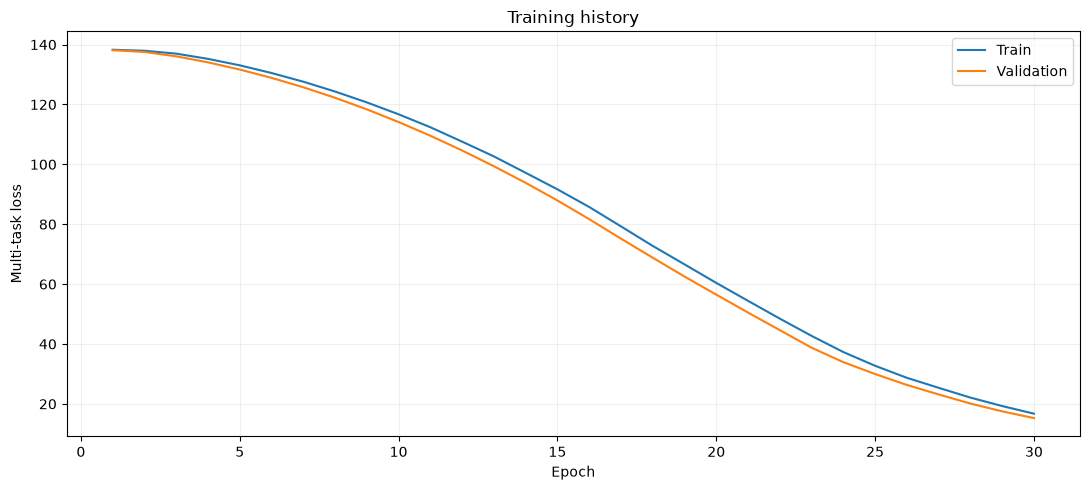

In [17]:
# ============================================================
# CELL 17 — Training loop with validation and early stopping
# ============================================================
EPOCHS = 30
PATIENCE = 6
best_val = np.inf
bad_epochs = 0
best_state = None

history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yr, ye, yq in train_loader:
        xb, yr, ye, yq = xb.to(DEVICE), yr.to(DEVICE), ye.to(DEVICE), yq.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        pr, pe, pq = model(xb)
        loss, lrain, lext, lq = multi_task_loss(pr, pe, pq, yr, ye, yq)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_losses.append([
            loss.item(), lrain.item(), lext.item(), lq.item()
        ])

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yr, ye, yq in val_loader:
            xb, yr, ye, yq = xb.to(DEVICE), yr.to(DEVICE), ye.to(DEVICE), yq.to(DEVICE)
            pr, pe, pq = model(xb)
            loss, lrain, lext, lq = multi_task_loss(pr, pe, pq, yr, ye, yq)
            val_losses.append([loss.item(), lrain.item(), lext.item(), lq.item()])

    tr = np.mean(train_losses, axis=0)
    va = np.mean(val_losses, axis=0)

    scheduler.step(va[0])

    history.append({
        "epoch": epoch,
        "train_total": tr[0],
        "val_total": va[0],
        "train_rain": tr[1],
        "val_rain": va[1],
        "train_extreme": tr[2],
        "val_extreme": va[2],
        "train_quantile": tr[3],
        "val_quantile": va[3],
        "lr": optimizer.param_groups[0]["lr"]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train={tr[0]:.4f} | val={va[0]:.4f} | "
        f"rain={va[1]:.4f} | ext={va[2]:.4f} | q95={va[3]:.4f}"
    )

    if va[0] < best_val - 1e-5:
        best_val = va[0]
        bad_epochs = 0
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print("Early stopping.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(history_df.epoch, history_df.train_total, label="Train")
ax.plot(history_df.epoch, history_df.val_total, label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Multi-task loss")
ax.set_title("Training history")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# CELL 18 — Generate test predictions
# ============================================================
model.eval()

all_prob = []
all_rain_z = []
all_quantile = []
all_true_ext = []
all_true_rain = []

with torch.no_grad():
    for xb, yr, ye, yq in test_loader:
        xb = xb.to(DEVICE)

        pr_z, pe_logits, pq = model(xb)

        all_rain_z.append(pr_z.cpu().numpy())
        all_prob.append(torch.sigmoid(pe_logits).cpu().numpy())
        all_quantile.append(pq.cpu().numpy())

        all_true_ext.append(ye.numpy())
        all_true_rain.append(yr.numpy())

pred_prob = np.concatenate(all_prob, axis=0)       # [samples,H,N]
pred_rain_z = np.concatenate(all_rain_z, axis=0)
pred_quantile = np.concatenate(all_quantile, axis=0)
true_ext = np.concatenate(all_true_ext, axis=0)
true_rain = np.concatenate(all_true_rain, axis=0)

# Convert standardized rainfall forecast back to mm.
mean_vec = means.reindex(subdivisions).values
std_vec = stds.reindex(subdivisions).values

pred_rain_mm = (
    pred_rain_z * std_vec[None,None,:] +
    mean_vec[None,None,:]
)
pred_rain_mm = np.clip(pred_rain_mm, 0, None)

print("Prediction shape:", pred_prob.shape)

Prediction shape: (208, 3, 36)


In [19]:
# ============================================================
# CELL 19 — Baselines: climatology and persistence
# ============================================================
# Extreme-event climatology baseline:
# training event frequency by subdivision × calendar month.
train_panel = panel[panel.DATE <= TRAIN_END].copy()
train_panel["MONTH"] = train_panel.DATE.dt.month

clim_prob = (
    train_panel.groupby(["MONTH","SUBDIVISION"])["EXTREME"]
    .mean()
)

# Persistence baseline:
# probability at each horizon is simply the last observed extreme state.
# It is intentionally simple and should not be interpreted as a strong
# benchmark.

test_target_indices = test_idx
persistence_prob = []

for i in test_target_indices:
    last_ext = extreme_array[i-1]
    persistence_prob.append(
        np.repeat(last_ext[None,:], HORIZON, axis=0)
    )

persistence_prob = np.stack(persistence_prob)

# Calendar climatology predictions for each test sample.
clim_predictions = []
for i in test_target_indices:
    vals = []
    for h in range(HORIZON):
        month = pd.Timestamp(date_values[i+h]).month
        vals.append([
            clim_prob.get((month,s), train_panel[
                train_panel.SUBDIVISION == s
            ].EXTREME.mean())
            for s in subdivisions
        ])
    clim_predictions.append(vals)

clim_predictions = np.asarray(clim_predictions, dtype=float)

print("Baselines prepared.")

Baselines prepared.


In [20]:
# ============================================================
# CELL 20 — Evaluation metrics by horizon and subdivision
# ============================================================
def safe_auc(y, p):
    if np.unique(y).size < 2:
        return np.nan
    return roc_auc_score(y, p)

def ece_score(y, p, n_bins=10):
    y = np.asarray(y)
    p = np.asarray(p)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (p >= lo) & (p < hi if hi < 1 else p <= hi)
        if mask.sum() == 0:
            continue
        ece += mask.mean() * abs(y[mask].mean() - p[mask].mean())
    return float(ece)

rows = []

for h in range(HORIZON):
    for j, s in enumerate(subdivisions):
        y = true_ext[:,h,j]
        p = pred_prob[:,h,j]

        auc = safe_auc(y,p)
        ap = average_precision_score(y,p)
        brier = brier_score_loss(y,p)
        ece = ece_score(y,p)

        clim = clim_predictions[:,h,j]
        persistence = persistence_prob[:,h,j]

        brier_clim = brier_score_loss(y, clim)
        brier_persist = brier_score_loss(y, persistence)

        bss_clim = 1 - brier / brier_clim if brier_clim > 0 else np.nan
        bss_persist = 1 - brier / brier_persist if brier_persist > 0 else np.nan

        rows.append({
            "subdivision": s,
            "horizon": h+1,
            "AUROC": auc,
            "AUPRC": ap,
            "Brier": brier,
            "ECE": ece,
            "BrierSkill_Climatology": bss_clim,
            "BrierSkill_Persistence": bss_persist,
            "GenuineSkill_AUROC": auc - 0.5 if pd.notna(auc) else np.nan
        })

metrics = pd.DataFrame(rows)

print("National mean metrics by horizon:")
display(
    metrics.groupby("horizon")[
        ["AUROC","AUPRC","Brier","ECE",
         "BrierSkill_Climatology","BrierSkill_Persistence",
         "GenuineSkill_AUROC"]
    ].mean().round(4)
)

National mean metrics by horizon:


,AUROC,AUPRC,Brier,ECE,BrierSkill_Climatology,BrierSkill_Persistence,GenuineSkill_AUROC
horizon,,,,,,,
1,0.8704,0.2376,0.1565,0.2914,-4.5898,-2.0665,0.3704
2,0.8771,0.2480,0.1528,0.2740,-4.5500,-1.8945,0.3771
3,0.8705,0.2045,0.1626,0.3155,-5.1282,-2.0579,0.3705


,horizon,RMSE_mm,MAE_mm,Q95_coverage
0,1,88.4095,51.1635,0.9776
1,2,87.7994,53.8677,0.9770
2,3,102.1452,63.3703,0.9774


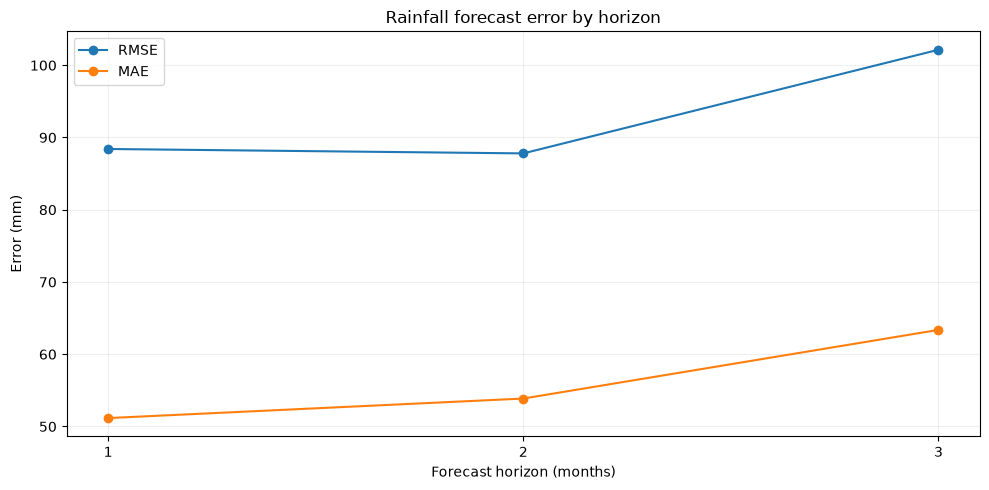

In [21]:
# ============================================================
# CELL 21 — Rainfall and quantile diagnostics
# ============================================================
reg_rows = []

for h in range(HORIZON):
    y = true_rain[:,h,:].ravel()
    p = pred_rain_mm[:,h,:].ravel()
    q = pred_quantile[:,h,:].ravel()

    rmse = mean_squared_error(y,p) ** 0.5
    mae = mean_absolute_error(y,p)

    # Empirical coverage of the predicted 95% quantile.
    coverage = np.mean(y <= q)

    reg_rows.append({
        "horizon": h+1,
        "RMSE_mm": rmse,
        "MAE_mm": mae,
        "Q95_coverage": coverage
    })

reg_metrics = pd.DataFrame(reg_rows)
display(reg_metrics.round(4))

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(reg_metrics.horizon, reg_metrics.RMSE_mm, marker="o", label="RMSE")
ax.plot(reg_metrics.horizon, reg_metrics.MAE_mm, marker="o", label="MAE")
ax.set_xticks(range(1,HORIZON+1))
ax.set_xlabel("Forecast horizon (months)")
ax.set_ylabel("Error (mm)")
ax.set_title("Rainfall forecast error by horizon")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

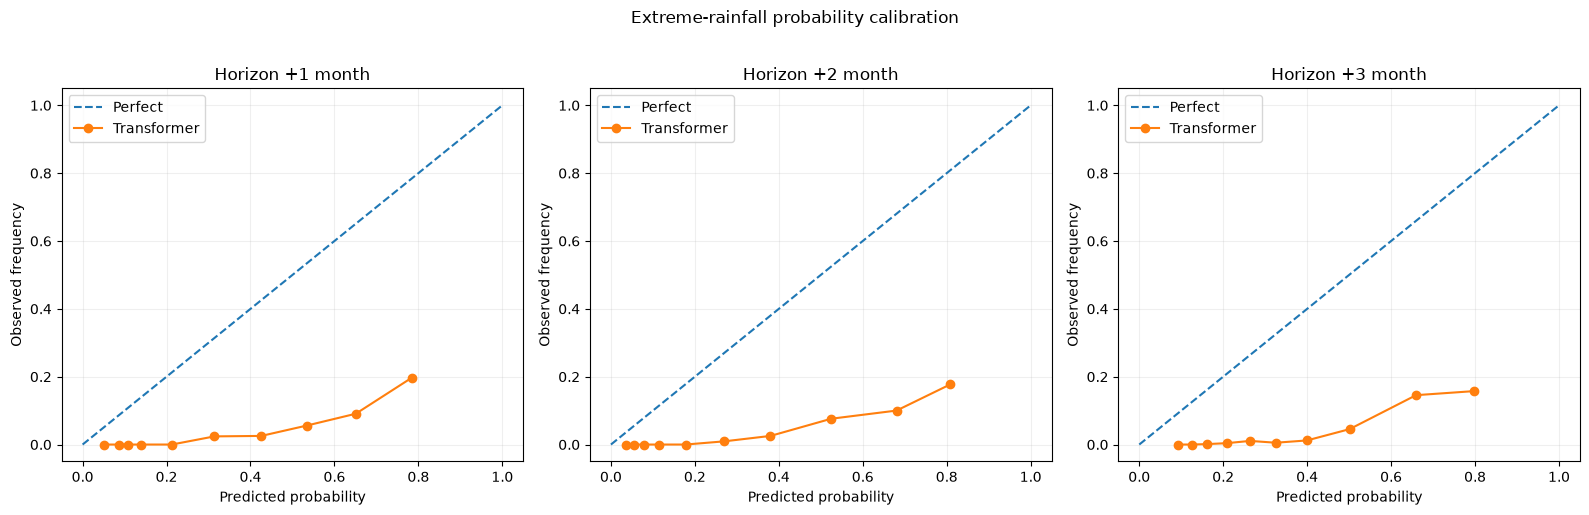

In [22]:
# ============================================================
# CELL 22 — Reliability diagrams for extreme-event probability
# ============================================================
fig, axes = plt.subplots(1, HORIZON, figsize=(16,5))

for h, ax in enumerate(axes):
    y = true_ext[:,h,:].ravel()
    p = pred_prob[:,h,:].ravel()

    frac_pos, mean_pred = calibration_curve(
        y, p, n_bins=10, strategy="quantile"
    )

    ax.plot([0,1], [0,1], linestyle="--", label="Perfect")
    ax.plot(mean_pred, frac_pos, marker="o", label="Transformer")
    ax.set_title(f"Horizon +{h+1} month")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.grid(alpha=0.2)
    ax.legend()

plt.suptitle("Extreme-rainfall probability calibration", y=1.02)
plt.tight_layout()
plt.show()

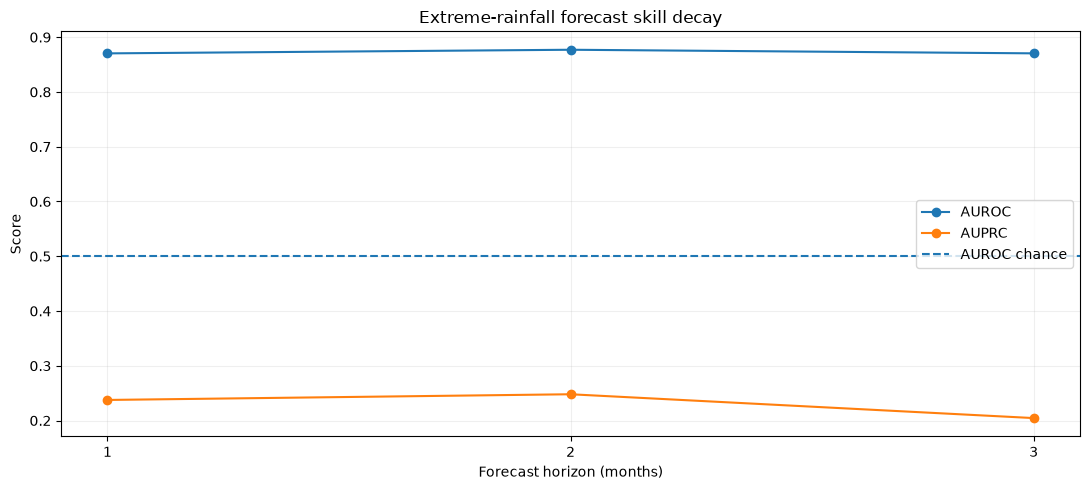

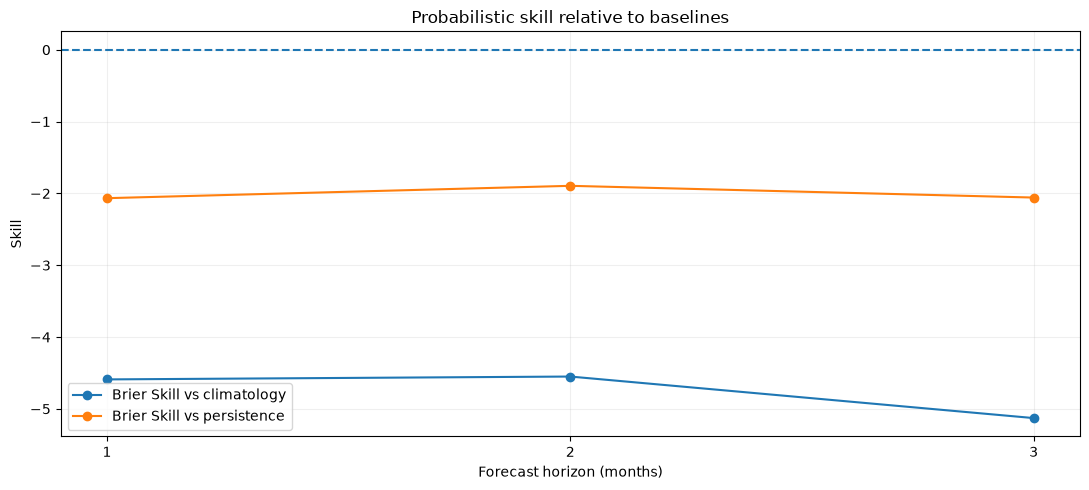

In [23]:
# ============================================================
# CELL 23 — Horizon-wise skill decay
# ============================================================
national = (
    metrics.groupby("horizon")
    [["AUROC","AUPRC","Brier","ECE",
      "BrierSkill_Climatology","BrierSkill_Persistence",
      "GenuineSkill_AUROC"]]
    .mean()
)

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(national.index, national.AUROC, marker="o", label="AUROC")
ax.plot(national.index, national.AUPRC, marker="o", label="AUPRC")
ax.axhline(0.5, linestyle="--", label="AUROC chance")
ax.set_xticks(range(1,HORIZON+1))
ax.set_xlabel("Forecast horizon (months)")
ax.set_ylabel("Score")
ax.set_title("Extreme-rainfall forecast skill decay")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(national.index, national.BrierSkill_Climatology,
        marker="o", label="Brier Skill vs climatology")
ax.plot(national.index, national.BrierSkill_Persistence,
        marker="o", label="Brier Skill vs persistence")
ax.axhline(0, linestyle="--")
ax.set_xticks(range(1,HORIZON+1))
ax.set_xlabel("Forecast horizon (months)")
ax.set_ylabel("Skill")
ax.set_title("Probabilistic skill relative to baselines")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 24 — Find the most skilful subdivisions
# ============================================================
skill_table = (
    metrics[metrics.horizon == 1]
    [["subdivision","AUROC","AUPRC","Brier","ECE",
      "BrierSkill_Climatology","BrierSkill_Persistence",
      "GenuineSkill_AUROC"]]
    .sort_values("GenuineSkill_AUROC", ascending=False)
)

display(skill_table.head(15).round(4))

# Stability across all horizons:
stability = (
    metrics.groupby("subdivision")
    .agg(
        mean_auc=("AUROC","mean"),
        mean_auprc=("AUPRC","mean"),
        mean_brier=("Brier","mean"),
        mean_ece=("ECE","mean"),
        mean_bss_clim=("BrierSkill_Climatology","mean"),
        mean_genuine_skill=("GenuineSkill_AUROC","mean")
    )
    .sort_values("mean_genuine_skill", ascending=False)
)

display(stability.head(15).round(4))

,subdivision,AUROC,AUPRC,Brier,ECE,BrierSkill_Climatology,BrierSkill_Persistence,GenuineSkill_AUROC
6,Coastal Karnataka,0.9563,0.4765,0.1297,0.2327,-4.0630,-1.6972,0.4563
17,Konkan & Goa,0.9537,0.5386,0.1177,0.2138,-4.3297,-0.3601,0.4537
31,Uttarakhand,0.9528,0.4543,0.1204,0.2373,-1.9835,-0.1383,0.4528
15,Jharkhand,0.9439,0.2377,0.1333,0.2739,-3.9879,-1.3097,0.4439
11,Gujarat Region,0.9428,0.3441,0.1268,0.2564,-2.5304,-0.3190,0.4428
32,Vidarbha,0.9394,0.5279,0.1247,0.2474,-2.6008,-0.6215,0.4394
3,Bihar,0.9379,0.2179,0.1627,0.2936,-6.4327,-2.3842,0.4379
34,West Rajasthan,0.9373,0.4249,0.1295,0.2555,-2.1271,-0.1221,0.4373
13,Himachal Pradesh,0.9372,0.0714,0.1531,0.3115,-8.1748,-14.9202,0.4372
24,Punjab,0.9338,0.3798,0.1516,0.3023,-5.9071,-2.9415,0.4338


,mean_auc,mean_auprc,mean_brier,mean_ece,mean_bss_clim,mean_genuine_skill
subdivision,,,,,,
West Rajasthan,0.9415,0.4609,0.1265,0.2416,-2.1886,0.4415
Konkan & Goa,0.9358,0.4312,0.1252,0.2428,-4.8627,0.4358
Chhattisgarh,0.9263,0.1425,0.1457,0.2674,-5.6562,0.4263
Jharkhand,0.9252,0.1969,0.1376,0.2625,-4.2290,0.4252
Orissa,0.9243,0.2618,0.1298,0.2457,-3.0183,0.4243
Gujarat Region,0.9231,0.3447,0.1370,0.2587,-2.8648,0.4231
West Madhya Pradesh,0.9227,0.3082,0.1364,0.2566,-3.4846,0.4227
Bihar,0.9202,0.1698,0.1585,0.2913,-6.3762,0.4202
Coastal Karnataka,0.9186,0.4051,0.1367,0.2632,-4.5021,0.4186


# 🗺️ The Extreme Rainfall Risk Atlas

The next cells obtain **real polygon boundaries** for India's IMD meteorological subdivisions.

The preferred source is the official IMD boundary endpoint, with a public IMD-subdivision GeoJSON fallback. The notebook **does not fabricate latitude/longitude coordinates**.

Because polygon-source availability can depend on Kaggle Internet settings, the map cell reports exactly which source was used.

In [25]:
# ============================================================
# CELL 25 — Download / locate actual IMD subdivision polygons
# ============================================================
MAP_DIR = Path("/kaggle/working/extreme_rainfall_risk_atlas")
MAP_DIR.mkdir(parents=True, exist_ok=True)
MAP_PATH = MAP_DIR / "imd_subdivisions.geojson"

IMD_MAP_URL = (
    "https://mausam.imd.gov.in/imd_latest/contents/"
    "district_shapefiles/sd_boundary.json"
)

FALLBACK_MAP_URL = (
    "https://raw.githubusercontent.com/datameet/maps/master/"
    "Meteorological_Subdivisions/IMD_Subdivisions.geojson"
)

def download_geojson(url, path):
    r = requests.get(
        url,
        timeout=30,
        headers={"User-Agent":"Mozilla/5.0"}
    )
    r.raise_for_status()
    payload = r.json()
    if "features" not in payload:
        raise ValueError("Downloaded object is not a GeoJSON FeatureCollection.")
    path.write_text(json.dumps(payload), encoding="utf-8")
    return payload

if not MAP_PATH.exists():
    try:
        download_geojson(IMD_MAP_URL, MAP_PATH)
        print("Map source: official IMD endpoint")
    except Exception as e1:
        print("Official IMD map download failed:", repr(e1))
        try:
            download_geojson(FALLBACK_MAP_URL, MAP_PATH)
            print("Map source: public IMD-subdivision GeoJSON fallback")
        except Exception as e2:
            raise RuntimeError(
                "Could not obtain actual IMD subdivision polygons. "
                "Enable Internet in Kaggle Notebook settings or attach an "
                "IMD subdivision GeoJSON as a dataset."
            ) from e2

gdf = gpd.read_file(MAP_PATH)

print("Polygon rows:", len(gdf))
print("CRS:", gdf.crs)
print("Columns:", list(gdf.columns))
display(gdf.head())

Map source: official IMD endpoint


Polygon rows: 36
CRS: EPSG:4326
Columns: ['OBJECTID_1', 'region_cod', 'subdivisio', 'STATE', 'Area', 'geometry']


,OBJECTID_1,region_cod,subdivisio,STATE,Area,geometry
0,1,SOUTH PENINSULA,LAKSHADWEEP,LAKSHADWEEP,272.893847,"MULTIPOLYGON (((-381976.1442 926288.2021, -382..."
1,2,SOUTH PENINSULA,A & N ISLAND,ANDAMAN AND NICOBAR ISLANDS,6153.324016,"MULTIPOLYGON (((1958996.3231 764107.0268, 1945..."
2,3,SOUTH PENINSULA,COASTAL ANDHRA PRADESH,ANDHRA PRADESH,96551.050874,"POLYGON ((421310.2194 1481570.6264, 411063.194..."
3,4,EAST AND NORTH EAST INDIA,ARUNACHAL PRADESH,ARUNACHAL PRADESH,86882.854752,"POLYGON ((1618402.1683 3030391.5114, 1603079.4..."
4,5,EAST AND NORTH EAST INDIA,ASSAM & MEGHALAYA,ASSAM,106109.790177,"POLYGON ((1925070.6639 3078434.4643, 1907712.5..."


In [26]:
# ============================================================
# CELL 26 — Inspect and normalize polygon names
# ============================================================
import re
import pandas as pd

# 1. Standardized normalization helper function
def norm_name(x):
    if pd.isna(x):
        return ""
    x = str(x).upper().strip()
    x = x.replace("&", " AND ")
    x = re.sub(r"[^A-Z0-9]+", " ", x)
    return re.sub(r"\s+", " ", x).strip()

# 2. Complete IMD Alias Mapping Dictionary
NAME_ALIASES = {
    "ANDAMAN AND NICOBAR ISLANDS": "A AND N ISLAND",
    "ANDAMAN AND NICOBAR": "A AND N ISLAND",
    "HARYANA DELHI AND CHANDIGARH": "HAR CHD AND DELHI",
    "HARYANA CHANDIGARH AND DELHI": "HAR CHD AND DELHI",
    "MATATHWADA": "MARATHWADA",
    "NAGA MANI MIZO TRIPURA": "N M M T",
    "NAGALAND MANIPUR MIZORAM TRIPURA": "N M M T",
    "NORTH INTERIOR KARNATAKA": "N I KARNATAKA",
    "RAYALSEEMA": "RAYALASEEMA",
    "SOUTH INTERIOR KARNATAKA": "S I KARNATAKA",
    "SUB HIMALAYAN WEST BENGAL AND SIKKIM": "SHWB AND SIKKIM",
    "SUB HIMALAYAN WEST BENGAL SIKKIM": "SHWB AND SIKKIM",
    "TAMIL NADU": "TAMILNADU AND PONDICHERY",
    "TAMIL NADU PUDUCHERRY AND KARAIKAL": "TAMILNADU AND PONDICHERY",
    "ORISSA": "ODISHA",
    "ARUNACHAL PRADESH": "ARUNACHAL PRADESH",
    "ARUNACHAL": "ARUNACHAL PRADESH",
    "SUB HIMALAYAN WEST BENGAL & SIKKIM": "SHWB AND SIKKIM",
    "GANGETIC WEST BENGAL": "GANGETIC WEST BENGAL",
}

# Symmetrical key resolution helper
def resolve_key(val):
    k = norm_name(val)
    return NAME_ALIASES.get(k, k)

# 3. Identify potential text/string columns in GeoDataFrame (type-agnostic)
gdf.columns = gdf.columns.astype(str)
object_cols = [
    c for c in gdf.columns
    if c.lower() != "geometry" and c != getattr(gdf, "_geometry_column_name", None) and (
        gdf[c].dtype == "object" or 
        pd.api.types.is_string_dtype(gdf[c]) or 
        pd.api.types.is_categorical_dtype(gdf[c])
    )
]

if not object_cols:
    object_cols = [c for c in gdf.columns if c != getattr(gdf, "_geometry_column_name", None)]

# 4. Generate lookup key mapping against original subdivisions list
rain_key_map = {s: resolve_key(s) for s in subdivisions}
rain_keys = set(rain_key_map.values())

# 5. Score candidate spatial columns against rainfall keys
scores = []
for c in object_cols:
    poly_keys = set(gdf[c].dropna().apply(resolve_key))
    overlap = len(rain_keys & poly_keys)
    scores.append((overlap, c))

scores.sort(reverse=True)

if not scores or scores[0][0] == 0:
    raise ValueError(
        f"No polygon field matches rainfall subdivision names. Candidate fields evaluated: {object_cols}"
    )

MAP_NAME_COL = scores[0][1]

# 6. Apply symmetrical keys to GeoDataFrame
gdf["KEY"] = gdf[MAP_NAME_COL].apply(resolve_key)
gdf["MAP_NAME"] = gdf[MAP_NAME_COL].map(norm_name)

# 7. Map back to exact original subdivision names required by subsequent evaluation cells
key_to_rain_name = {v: k for k, v in rain_key_map.items()}
gdf["RAIN_NAME"] = gdf["KEY"].map(key_to_rain_name)

matched = gdf["RAIN_NAME"].notna().sum()
total_subdivisions = len(subdivisions)

print(f"Selected polygon name field: '{MAP_NAME_COL}'")
print(f"Matched rainfall subdivisions: {matched}/{total_subdivisions}")

# 8. Alignment verification check
if matched == total_subdivisions:
    print("SUCCESS: 100% 1-to-1 key alignment achieved between DataFrame and GeoDataFrame.")
else:
    unmatched = sorted(set(subdivisions) - set(gdf["RAIN_NAME"].dropna()))
    print(f"\nWARNING: Unmatched rainfall subdivisions ({len(unmatched)}):")
    for x in unmatched:
        print(" ", x)

display(gdf[[MAP_NAME_COL, "MAP_NAME", "RAIN_NAME"]].head(20))


Selected polygon name field: 'subdivisio'
Matched rainfall subdivisions: 36/36
SUCCESS: 100% 1-to-1 key alignment achieved between DataFrame and GeoDataFrame.


,subdivisio,MAP_NAME,RAIN_NAME
0,LAKSHADWEEP,LAKSHADWEEP,Lakshadweep
1,A & N ISLAND,A AND N ISLAND,Andaman & Nicobar Islands
2,COASTAL ANDHRA PRADESH,COASTAL ANDHRA PRADESH,Coastal Andhra Pradesh
3,ARUNACHAL PRADESH,ARUNACHAL PRADESH,Arunachal Pradesh
4,ASSAM & MEGHALAYA,ASSAM AND MEGHALAYA,Assam & Meghalaya
5,BIHAR,BIHAR,Bihar
6,KONKAN & GOA,KONKAN AND GOA,Konkan & Goa
7,SAURASHTRA & KUTCH,SAURASHTRA AND KUTCH,Saurashtra & Kutch
8,HAR. CHD & DELHI,HAR CHD AND DELHI,Haryana Delhi & Chandigarh
9,HIMACHAL PRADESH,HIMACHAL PRADESH,Himachal Pradesh


In [27]:
# ============================================================
# CELL 27 — Explicit name reconciliation & polygon filtering
# ============================================================
# Filter GeoDataFrame to include only valid matched rainfall subdivisions
gdf_match = gdf[gdf["RAIN_NAME"].isin(subdivisions)].copy()

if gdf_match.empty:
    raise ValueError(
        "Polygon layer loaded, but subdivision names could not be matched. "
        "Inspect gdf columns and update aliases for the map source."
    )

print(f"Matched polygons after aliases: {len(gdf_match)}")
print(f"Subdivision coverage: {len(gdf_match)}/{len(subdivisions)}")

# Optional: Output verification preview
display(gdf_match[["MAP_NAME", "RAIN_NAME"]].head(10))


Matched polygons after aliases: 36
Subdivision coverage: 36/36


,MAP_NAME,RAIN_NAME
0,LAKSHADWEEP,Lakshadweep
1,A AND N ISLAND,Andaman & Nicobar Islands
2,COASTAL ANDHRA PRADESH,Coastal Andhra Pradesh
3,ARUNACHAL PRADESH,Arunachal Pradesh
4,ASSAM AND MEGHALAYA,Assam & Meghalaya
5,BIHAR,Bihar
6,KONKAN AND GOA,Konkan & Goa
7,SAURASHTRA AND KUTCH,Saurashtra & Kutch
8,HAR CHD AND DELHI,Haryana Delhi & Chandigarh
9,HIMACHAL PRADESH,Himachal Pradesh


In [28]:
# ============================================================
# CELL 28 — Build final map metrics
# ============================================================
# Choose the first forecast horizon as the operational near-term atlas.
map_horizon = 1

map_metrics = metrics[metrics.horizon == map_horizon].copy()

# A practical composite:
# probability = mean predicted extreme probability over test samples.
# skill = AUROC - 0.5, where >0 means above chance.
mean_prob_by_sub = {}
for j, s in enumerate(subdivisions):
    mean_prob_by_sub[s] = float(pred_prob[:,map_horizon-1,j].mean())

map_metrics["MeanExtremeProbability"] = (
    map_metrics.subdivision.map(mean_prob_by_sub)
)

# Add Q95 and event rate.
map_metrics["Q95_mm"] = map_metrics.subdivision.map(q95.to_dict())

test_event_rate = (
    pd.DataFrame(true_ext[:,map_horizon-1,:], columns=subdivisions)
    .mean()
    .to_dict()
)
map_metrics["ObservedTestExtremeRate"] = (
    map_metrics.subdivision.map(test_event_rate)
)

gmap = gdf_match.merge(
    map_metrics,
    left_on="RAIN_NAME",
    right_on="subdivision",
    how="left"
)

print("Final map rows:", len(gmap))
display(
    gmap[[
        "subdivision","AUROC","AUPRC","Brier","ECE",
        "BrierSkill_Climatology","GenuineSkill_AUROC",
        "MeanExtremeProbability","Q95_mm"
    ]].sort_values("GenuineSkill_AUROC", ascending=False).head(15)
)

Final map rows: 36


,subdivision,AUROC,AUPRC,Brier,ECE,BrierSkill_Climatology,GenuineSkill_AUROC,MeanExtremeProbability,Q95_mm
31,Coastal Karnataka,0.956271,0.476527,0.129671,0.232746,-4.063000,0.456271,0.261592,1129.69
6,Konkan & Goa,0.953657,0.538628,0.117702,0.213848,-4.329650,0.453657,0.257117,1090.38
23,Uttarakhand,0.952806,0.454314,0.120400,0.237347,-1.983525,0.452806,0.295039,449.05
22,Jharkhand,0.943894,0.237729,0.133251,0.273929,-3.987937,0.443894,0.302775,378.03
25,Gujarat Region,0.942778,0.344079,0.126827,0.256378,-2.530361,0.442778,0.309263,372.53
33,Vidarbha,0.939394,0.527941,0.124730,0.247394,-2.600764,0.439394,0.295471,364.48
5,Bihar,0.937931,0.217903,0.162701,0.293629,-6.432724,0.437931,0.317668,366.00
18,West Rajasthan,0.937278,0.424920,0.129477,0.255544,-2.127124,0.437278,0.318044,119.65
9,Himachal Pradesh,0.937198,0.071429,0.153079,0.311488,-8.174828,0.437198,0.316296,348.87
17,Punjab,0.933824,0.379751,0.151596,0.302301,-5.907118,0.433824,0.321531,209.56


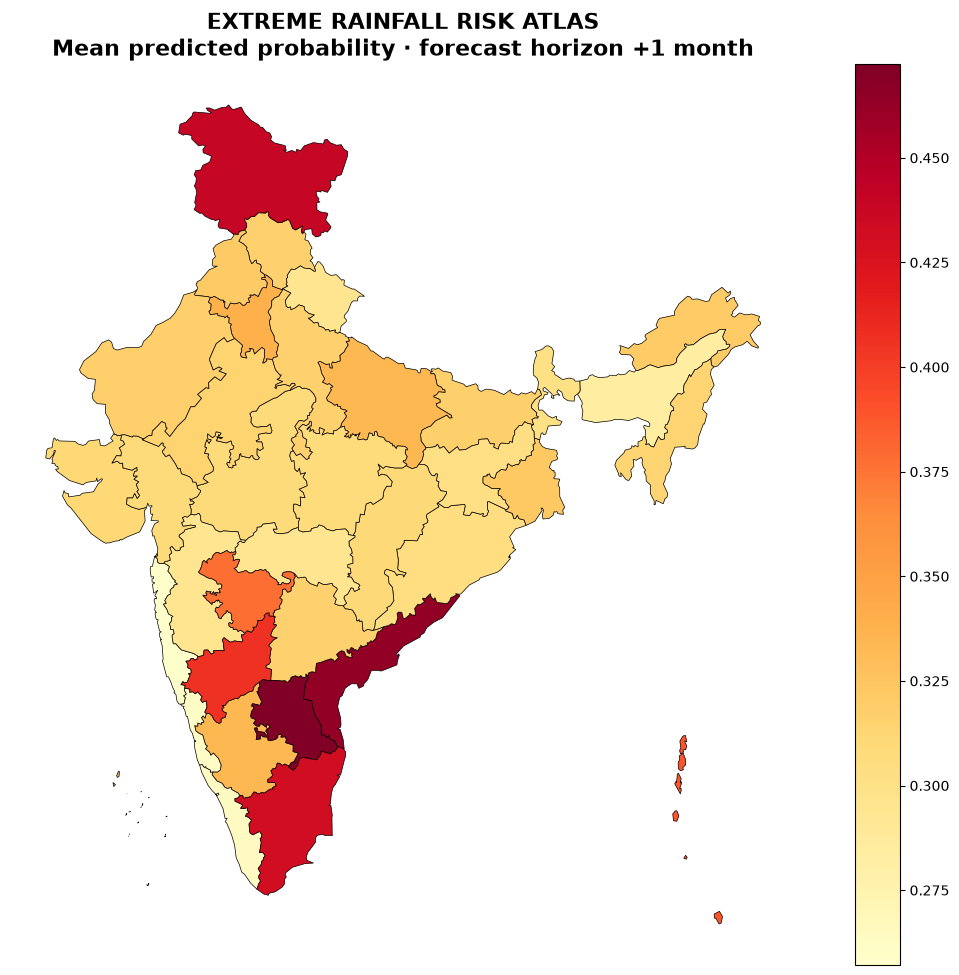

In [29]:
# ============================================================
# CELL 29 — ACTUAL MAP: probability of extreme rainfall
# ============================================================
fig, ax = plt.subplots(figsize=(12, 10))

gmap.plot(
    column="MeanExtremeProbability",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    aspect="equal",  # Fixes Matplotlib non-finite aspect ratio error
    missing_kwds={"color": "lightgrey", "label": "Unmatched / unavailable"},
    ax=ax
)

ax.set_title(
    "EXTREME RAINFALL RISK ATLAS\n"
    "Mean predicted probability · forecast horizon +1 month",
    fontsize=16,
    fontweight="bold"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


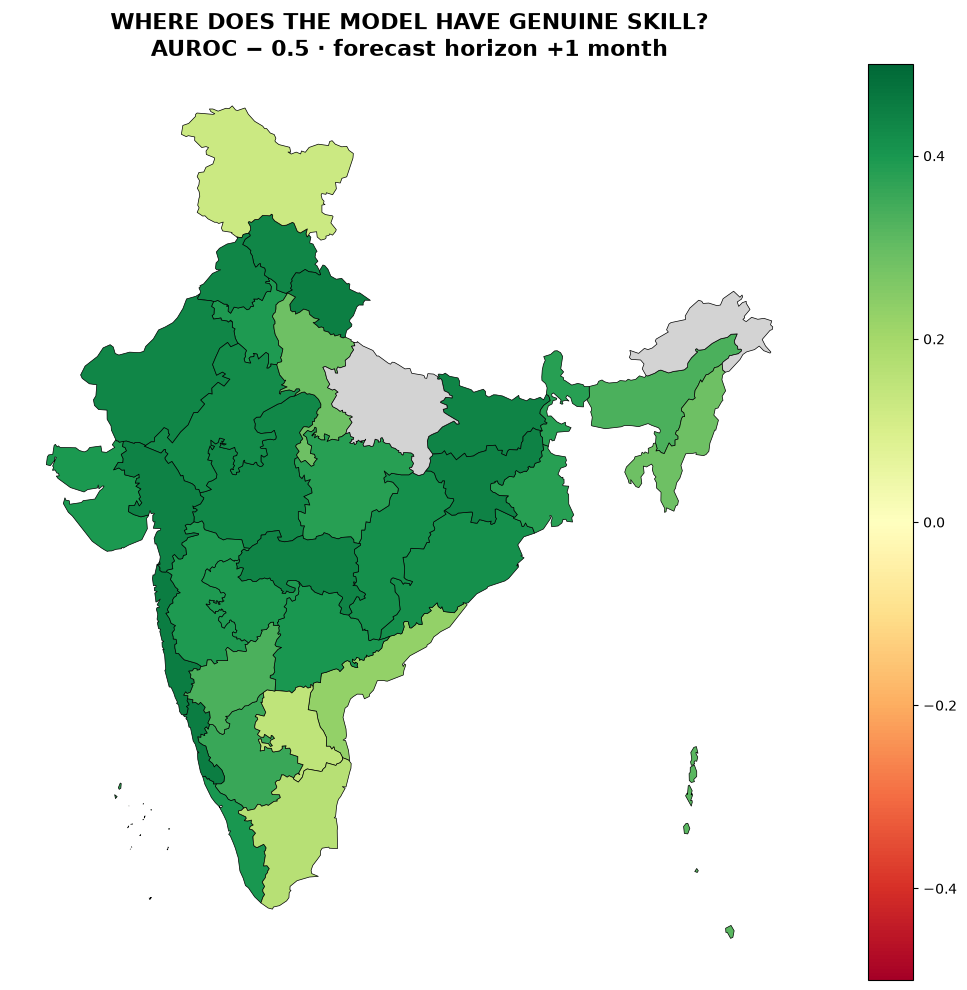

In [30]:
# ============================================================
# CELL 30 — THE KEY MAP: where does the model have genuine skill?
# ============================================================
# Genuine skill here is explicitly defined as:
#
#     AUROC - 0.5
#
# Therefore:
#   > 0  = above-chance discrimination
#   = 0  = chance-level discrimination
#   < 0  = below chance
#
# This is deliberately NOT called "causal climate skill".

fig, ax = plt.subplots(figsize=(12, 10))

gmap.plot(
    column="GenuineSkill_AUROC",
    cmap="RdYlGn",
    vmin=-0.5,
    vmax=0.5,
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    aspect="equal",  # Prevents Matplotlib non-finite aspect ratio error
    missing_kwds={"color": "lightgrey"},
    ax=ax
)

ax.set_title(
    "WHERE DOES THE MODEL HAVE GENUINE SKILL?\n"
    "AUROC − 0.5 · forecast horizon +1 month",
    fontsize=16,
    fontweight="bold"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()


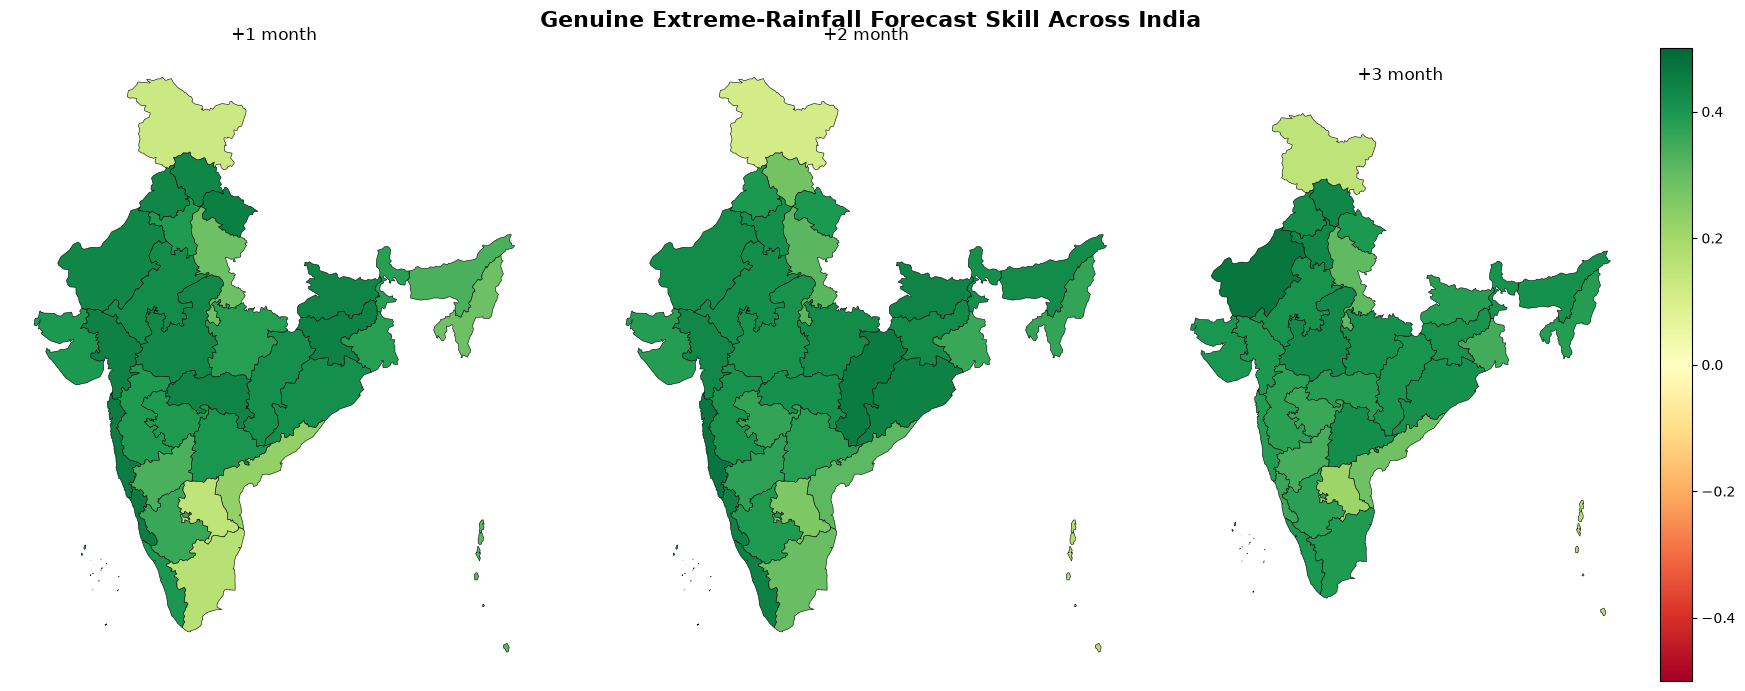

In [31]:
# ============================================================
# CELL 31 — Multi-horizon genuine-skill maps
# ============================================================
fig, axes = plt.subplots(
    1, HORIZON, figsize=(18, 7)
)

for h, ax in enumerate(axes, start=1):
    hm = metrics[metrics.horizon == h].copy()
    gm = gdf_match.merge(
        hm,
        left_on="RAIN_NAME",
        right_on="subdivision",
        how="left"
    )

    gm.plot(
        column="GenuineSkill_AUROC",
        cmap="RdYlGn",
        vmin=-0.5,
        vmax=0.5,
        linewidth=0.4,
        edgecolor="black",
        legend=(h == HORIZON),
        aspect="equal",  # Fixes Matplotlib non-finite aspect ratio error
        ax=ax
    )

    ax.set_title(f"+{h} month")
    ax.set_axis_off()

plt.suptitle(
    "Genuine Extreme-Rainfall Forecast Skill Across India",
    fontsize=16,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


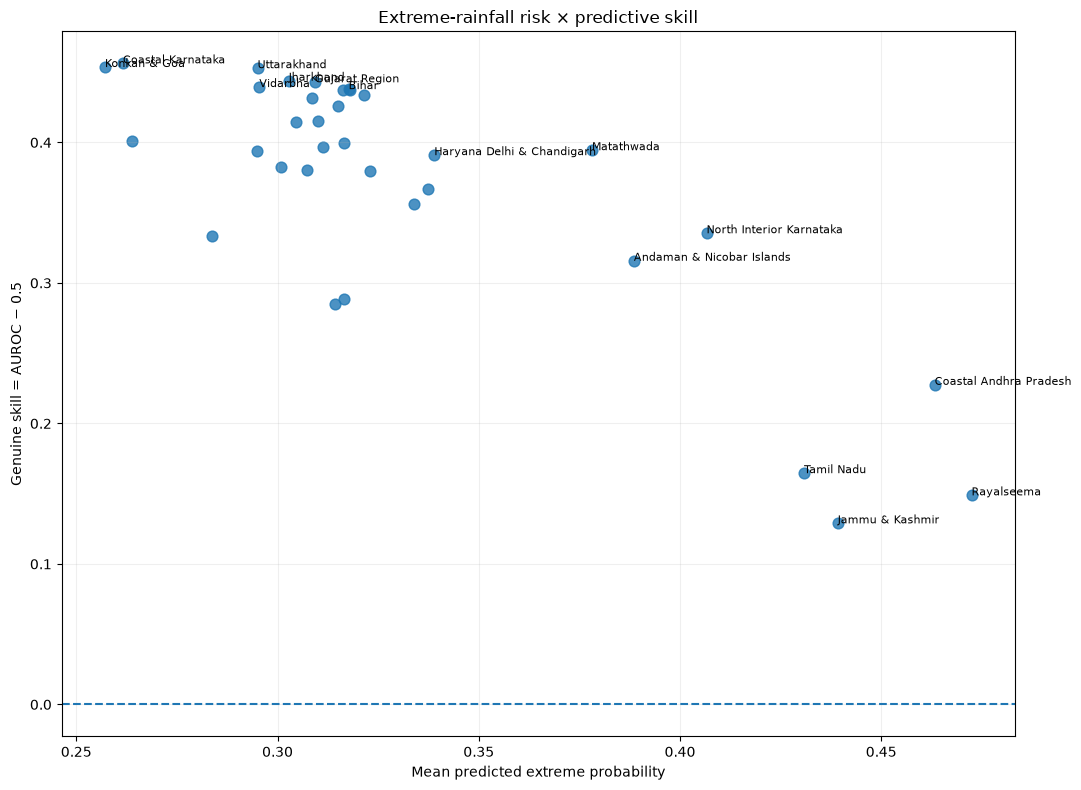

In [32]:
# ============================================================
# CELL 32 — Risk × skill quadrant
# ============================================================
# Operational interpretation:
# High risk + high skill = highest-priority forecast regions.
# High risk + low skill = high hazard but weak predictive confidence.
# Low risk + high skill = predictable but relatively infrequent extremes.

fig, ax = plt.subplots(figsize=(11,8))

x = map_metrics["MeanExtremeProbability"]
y = map_metrics["GenuineSkill_AUROC"]

ax.scatter(x, y, s=60, alpha=0.8)

for _, r in map_metrics.iterrows():
    if (
        r["MeanExtremeProbability"] >= map_metrics["MeanExtremeProbability"].quantile(0.80)
        or r["GenuineSkill_AUROC"] >= map_metrics["GenuineSkill_AUROC"].quantile(0.80)
    ):
        ax.annotate(
            r["subdivision"],
            (r["MeanExtremeProbability"], r["GenuineSkill_AUROC"]),
            fontsize=8
        )

ax.axhline(0, linestyle="--")
ax.set_xlabel("Mean predicted extreme probability")
ax.set_ylabel("Genuine skill = AUROC − 0.5")
ax.set_title("Extreme-rainfall risk × predictive skill")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# CELL 33 — Export research tables and model
# ============================================================
OUTPUT_DIR = Path("/kaggle/working/extreme_rainfall_risk_atlas")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metrics.to_csv(OUTPUT_DIR / "extreme_rainfall_metrics_by_subdivision_horizon.csv", index=False)
stability.to_csv(OUTPUT_DIR / "subdivision_skill_summary.csv")
threshold_table.to_csv(OUTPUT_DIR / "training_q95_thresholds.csv", index=False)
reg_metrics.to_csv(OUTPUT_DIR / "rainfall_regression_metrics.csv", index=False)

torch.save({
    "model_state_dict": model.state_dict(),
    "subdivisions": subdivisions,
    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "q95_train": q95.to_dict(),
    "train_means": means.to_dict(),
    "train_stds": stds.to_dict(),
    "seed": SEED,
}, OUTPUT_DIR / "multitask_extreme_rainfall_transformer.pt")

print("Saved outputs to:", OUTPUT_DIR)
print(*sorted(str(p) for p in OUTPUT_DIR.iterdir()), sep="\n")

Saved outputs to: /kaggle/working/extreme_rainfall_risk_atlas
/kaggle/working/extreme_rainfall_risk_atlas/extreme_rainfall_metrics_by_subdivision_horizon.csv
/kaggle/working/extreme_rainfall_risk_atlas/imd_subdivisions.geojson
/kaggle/working/extreme_rainfall_risk_atlas/multitask_extreme_rainfall_transformer.pt
/kaggle/working/extreme_rainfall_risk_atlas/rainfall_regression_metrics.csv
/kaggle/working/extreme_rainfall_risk_atlas/subdivision_skill_summary.csv
/kaggle/working/extreme_rainfall_risk_atlas/training_q95_thresholds.csv


# 🔬 Interpretation and scientific cautions

### What the atlas can legitimately say

A subdivision with:

- **AUROC > 0.5** has above-chance discrimination in this held-out temporal test period.
- **Higher AUPRC** means better identification of the relatively uncommon extreme class.
- **Lower Brier score** means better probabilistic accuracy.
- **Lower ECE** means better calibration.
- **Positive Brier Skill Score** means improvement over the selected baseline.
- **Positive GenuineSkill_AUROC** means AUROC above chance.

### What it cannot say

This is **not causal climate attribution**. Forecast skill can arise from rainfall persistence, seasonality, autocorrelation and other statistical structure.

The map is a **meteorological-subdivision forecast-skill atlas**, not a district-level disaster-risk map.

The Q95 threshold used for model evaluation is deliberately **training-only**. A separate full-history Q95 may be calculated for descriptive climate analysis, but it must not replace the leakage-controlled threshold in the predictive experiment.

### Recommended publication upgrades

For a paper-quality extension, add:

1. rolling-origin evaluation;
2. confidence intervals via block bootstrap;
3. seasonal-climatology and autoregressive baselines;
4. Transformer-only vs classical ablations;
5. ENSO/IOD/SST covariates;
6. spatial adjacency or graph attention;
7. permutation tests for spatial skill;
8. event-based metrics such as recall at operational probability thresholds.

The central scientific result should be the **spatial distribution of incremental probabilistic skill**, not simply the use of a Transformer.

## 🏁 Final research statement

> **This notebook estimates where historical rainfall contains enough predictive information for a multi-task Transformer to anticipate subdivision-specific extreme rainfall, evaluates that probability out-of-sample using AUROC, AUPRC, Brier score and calibration, and projects the resulting forecast risk and genuine above-chance skill onto actual IMD meteorological subdivision polygons.**